Brianna Lannerd
09/10/2026
Lab 3 - Oscillator

In [9]:
#Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt


Part A- The Simple Harmonic Oscillator

In [10]:
# Parameters
k = 1.0     # spring constant (N/m)
m = 1.0     # mass (kg)
omega0 = np.sqrt(k / m)   # natural frequency
T = 2 * np.pi / omega0      # period

# Initial conditions
x0 = 1.0    # initial displacement (m)
v0 = 0.0    # released from rest

# Exact solution for comparison
def exact_x(t):
    return x0 * np.cos(omega0 * t)

def exact_v(t):
    return -x0 * omega0 * np.sin(omega0 * t)

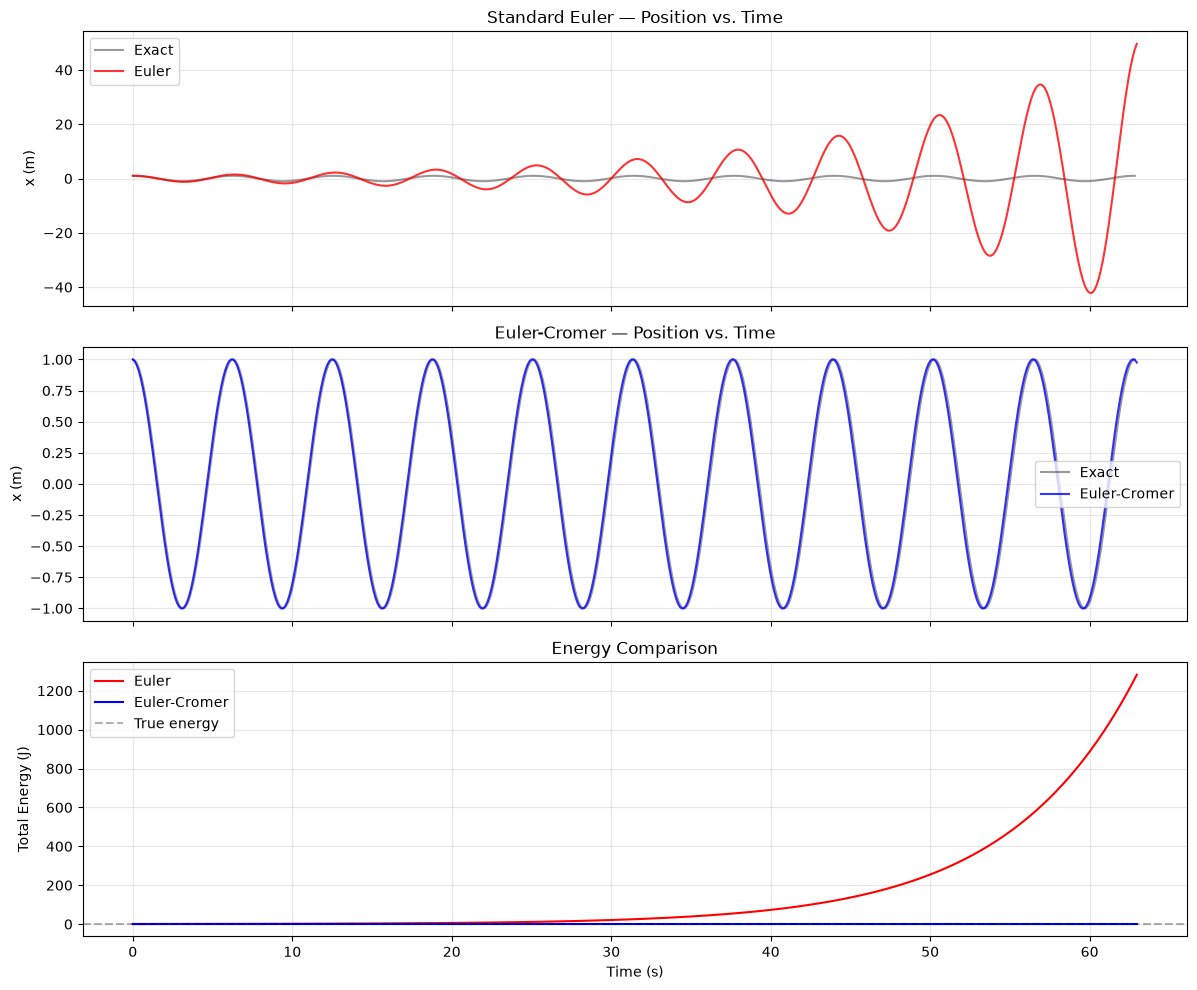

In [ ]:
#Part A: Section 1: 
def simulate_sho(method, dt, n_periods=10):
    """Simulate SHO. Returns t, x, v, E arrays."""
    t_max = n_periods * T
    x, v = x0, v0
    ts, xs, vs, Es = [0], [x], [v], [0.5*k*x**2 + 0.5*m*v**2]
    t = 0.0

    while t < t_max:
        a = -(k / m) * x

        if method == 'euler':
            x_new = x + v * dt
            v_new = v + a * dt
            x, v = x_new, v_new
        elif method == 'euler-cromer':
            v = v + a * dt       # velocity first
            x = x + v * dt       # then position with new v

        t += dt
        E = 0.5 * k * x**2 + 0.5 * m * v**2
        ts.append(t); xs.append(x); vs.append(v); Es.append(E)

    return np.array(ts), np.array(xs), np.array(vs), np.array(Es)

#Part A: Section 2
# Run both with dt = T/50 
dt = T / 50
t_e, x_e, v_e, E_e = simulate_sho('euler', dt)
t_ec, x_ec, v_ec, E_ec = simulate_sho('euler-cromer', dt)
t_exact = np.linspace(0, 10*T, 2000)

#Part A: Section 3 and 4
#Plot: x(t) comparison 
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(t_exact, exact_x(t_exact), 'k-', alpha=0.4, label='Exact')
axes[0].plot(t_e, x_e, 'r-', alpha=0.8, label='Euler')
axes[0].set_ylabel('x (m)')
axes[0].set_title('Standard Euler — Position vs. Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_exact, exact_x(t_exact), 'k-', alpha=0.4, label='Exact')
axes[1].plot(t_ec, x_ec, 'b-', alpha=0.8, label='Euler-Cromer')
axes[1].set_ylabel('x (m)')
axes[1].set_title('Euler-Cromer — Position vs. Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_e, E_e, 'r-', label='Euler')
axes[2].plot(t_ec, E_ec, 'b-', label='Euler-Cromer')
axes[2].axhline(y=E_e[0], color='k', linestyle='--', alpha=0.3, label='True energy')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Total Energy (J)')
axes[2].set_title('Energy Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Standard Euler: For the position vs time graph, the solution’s amplitude gets larger with each oscillation instead of staying constant like the exact solution. This shows that standard Euler has an error that results in the system gaining energy over time.

Euler Cromer: For the position vs time graph, the Euler-Cromer solution stays very close to the exact solution during all 10 periods. The amplitude is approximately cosntant. This shows that Euler-Cromer is better for systems that oscillate. 

Energy Comparison Graph: The standard Euler method causes the calculated energy to increase rapidly, even though the actual energy of the system baed on physics shouldn't change. Euler-Cromer shows the energy conservation a lot better than the standard euler method. 

In [12]:
simulate_sho('euler', dt=0.05, n_periods=10)

(array([0.000e+00, 5.000e-02, 1.000e-01, ..., 6.275e+01, 6.280e+01,
        6.285e+01], shape=(1258,)),
 array([1.        , 1.        , 0.9975    , ..., 4.74826063, 4.78028183,
        4.80043238], shape=(1258,)),
 array([ 0.        , -0.05      , -0.1       , ...,  0.64042396,
         0.40301093,  0.16399684], shape=(1258,)),
 array([ 0.5       ,  0.50125   ,  0.50250313, ..., 11.47806094,
        11.50675609, 11.53552298], shape=(1258,)))

Part A, Section 5:
Over the 10 periods, the standard Euler amplitude appears to become larger and larger instead of staying constant. Its total energy also increases quickly, showing that the way the standard Euler approximates this problem actually adds energy to the simulation. Euler-Cromer, on the other hand, doesn't have this same problem. Instead, its amplitude stays close to the exact solution and its energy remains approximately constant which is what you would expect based on the physics. .


Part B: Phase Space and Damed Oscillations

B.1 Phase-space portraits

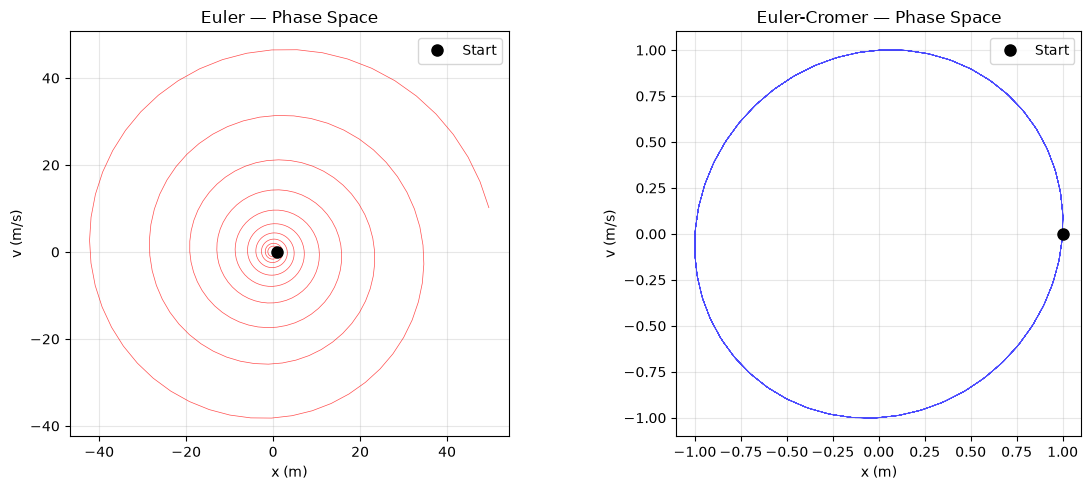

In [ ]:
#Part B: Section 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Euler phase portrait
ax1.plot(x_e, v_e, 'r-', alpha=0.7, linewidth=0.5)
ax1.plot(x_e[0], v_e[0], 'ko', markersize=8, label='Start')
ax1.set_xlabel('x (m)'); ax1.set_ylabel('v (m/s)')
ax1.set_title('Euler — Phase Space')
ax1.set_aspect('equal')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Euler-Cromer phase portrait
ax2.plot(x_ec, v_ec, 'b-', alpha=0.7, linewidth=0.5)
ax2.plot(x_ec[0], v_ec[0], 'ko', markersize=8, label='Start')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('v (m/s)')
ax2.set_title('Euler-Cromer — Phase Space')
ax2.set_aspect('equal')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Part B: Section 2: The Euler curve spirals outward, showing that the amplitude and energy are increasing over time because of numerical error. The Euler-Cromer curve stays in a nearly closed loop, which matches the energy plot where the total energy remains approximately constant. This reflects how the euler cromer is a better approximation method for oscillating systems compared to standard euler. 

dt= T/20

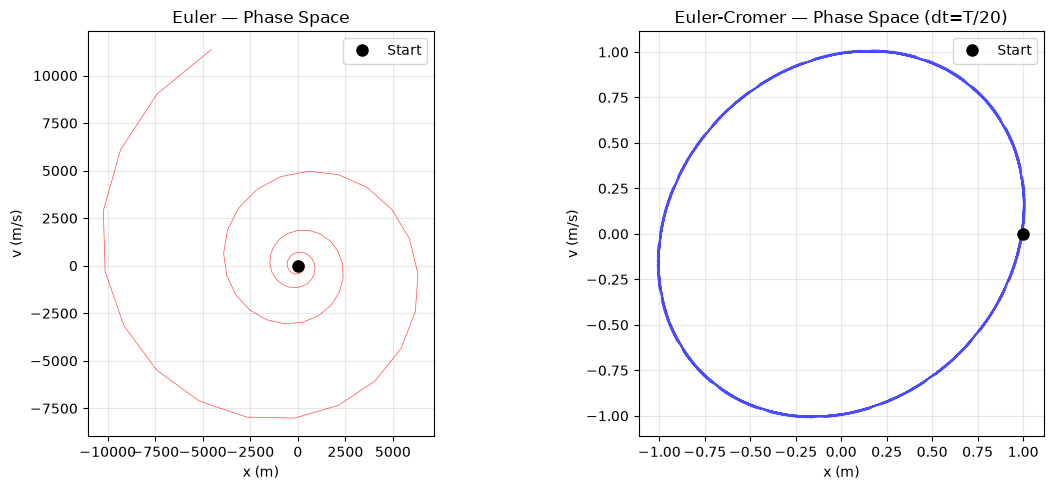

In [14]:
dt = T / 20
t_e, x_e, v_e, E_e = simulate_sho('euler', dt)
t_ec, x_ec, v_ec, E_ec = simulate_sho('euler-cromer', dt)
t_exact = np.linspace(0, 10*T, 2000)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Euler phase portrait
ax1.plot(x_e, v_e, 'r-', alpha=0.7, linewidth=0.5)
ax1.plot(x_e[0], v_e[0], 'ko', markersize=8, label='Start')
ax1.set_xlabel('x (m)'); ax1.set_ylabel('v (m/s)')
ax1.set_title('Euler — Phase Space')
ax1.set_aspect('equal')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Euler-Cromer phase portrait
ax2.plot(x_ec, v_ec, 'b-', alpha=0.7, linewidth=0.5)
ax2.plot(x_ec[0], v_ec[0], 'ko', markersize=8, label='Start')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('v (m/s)')
ax2.set_title('Euler-Cromer — Phase Space (dt=T/20)')
ax2.set_aspect('equal')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Graphs below are not for assignment, but experimenting with the code per module 3 lesson.

dt=T/200

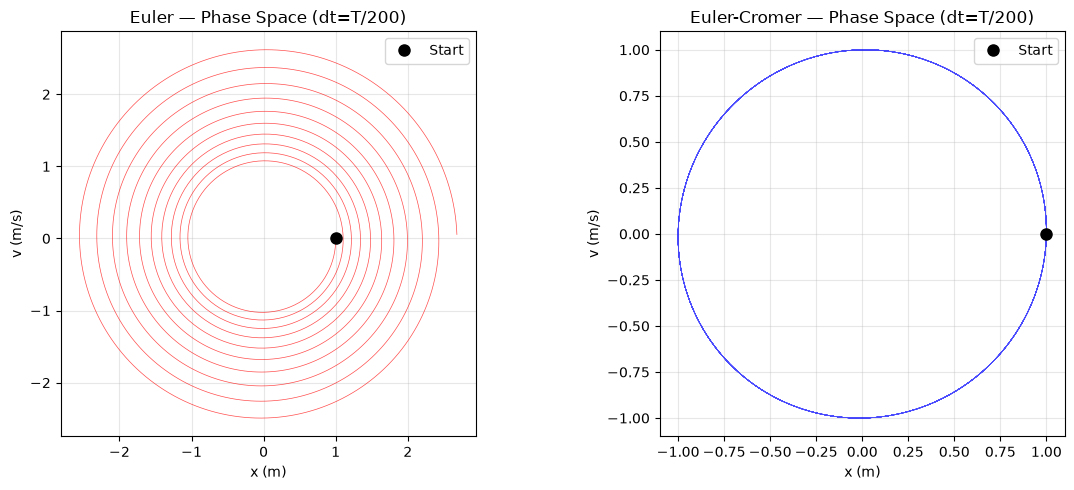

In [15]:
dt = T / 200
t_e, x_e, v_e, E_e = simulate_sho('euler', dt)
t_ec, x_ec, v_ec, E_ec = simulate_sho('euler-cromer', dt)
t_exact = np.linspace(0, 10*T, 2000)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Euler phase portrait
ax1.plot(x_e, v_e, 'r-', alpha=0.7, linewidth=0.5)
ax1.plot(x_e[0], v_e[0], 'ko', markersize=8, label='Start')
ax1.set_xlabel('x (m)'); ax1.set_ylabel('v (m/s)')
ax1.set_title('Euler — Phase Space (dt=T/200)')
ax1.set_aspect('equal')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Euler-Cromer phase portrait
ax2.plot(x_ec, v_ec, 'b-', alpha=0.7, linewidth=0.5)
ax2.plot(x_ec[0], v_ec[0], 'ko', markersize=8, label='Start')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('v (m/s)')
ax2.set_title('Euler-Cromer — Phase Space (dt=T/200)')
ax2.set_aspect('equal')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

B.2 Add Damping

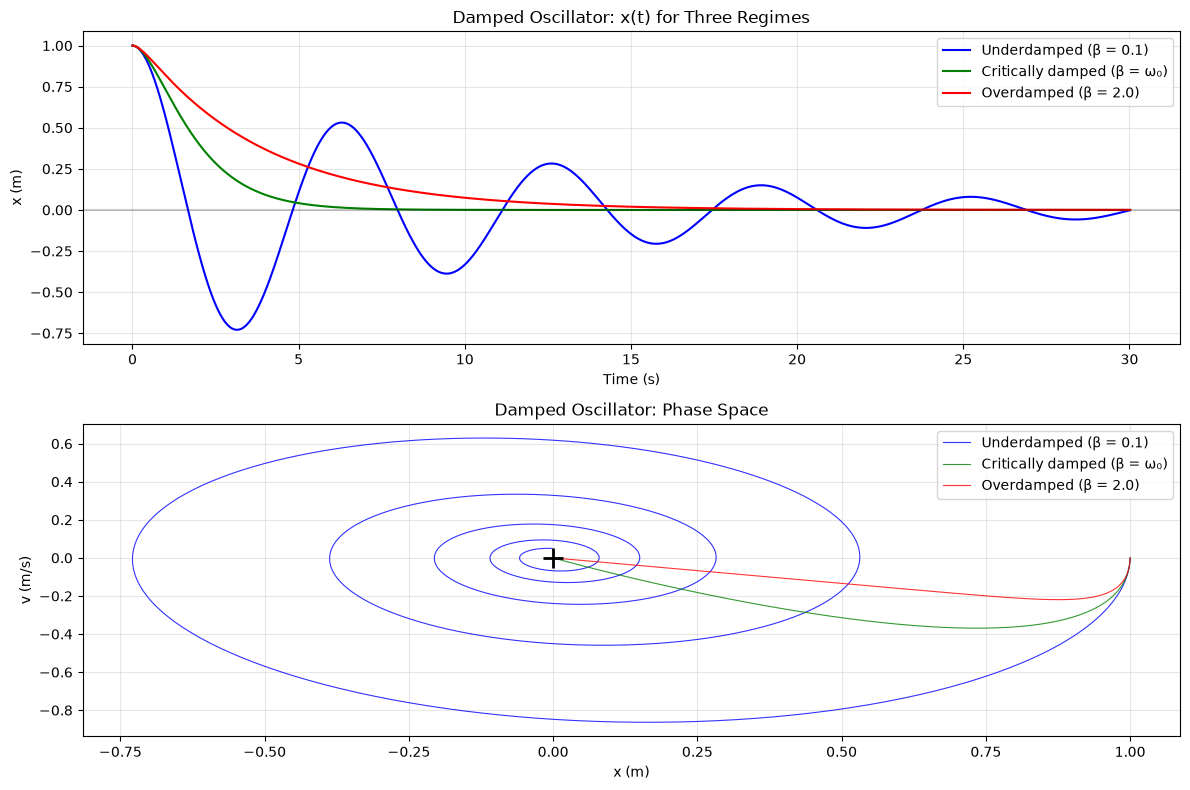

In [ ]:
#Part B.2: Section 1
def simulate_damped_sho(beta, dt=0.02, t_max=30.0):
    """Simulate damped SHO with Euler-Cromer.
    beta = b/(2m) is the damping parameter.
    """
    x, v = x0, v0
    b_damp = 2 * m * beta  # recover b from beta
    ts, xs, vs = [0], [x], [v]
    t = 0.0

    while t < t_max:
        # Force: spring + linear damping
        a = -(k / m) * x - (b_damp / m) * v

        # Euler-Cromer
        v = v + a * dt
        x = x + v * dt
        t += dt
        ts.append(t); xs.append(x); vs.append(v)

    return np.array(ts), np.array(xs), np.array(vs)

#Part B.2: Section 2
#Compare three damping regimes
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

regimes = [
    (0.1,  'Underdamped (β = 0.1)',   'b'),
    (omega0, 'Critically damped (β = ω₀)', 'g'),
    (2.0,  'Overdamped (β = 2.0)',     'r'),
]

for beta, label, color in regimes:
    t, x, v = simulate_damped_sho(beta)
    axes[0].plot(t, x, color=color, label=label, linewidth=1.5)
    axes[1].plot(x, v, color=color, label=label, linewidth=0.8, alpha=0.8)

#Part B.2: Section 3
# x(t) plot
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('x (m)')
axes[0].set_title('Damped Oscillator: x(t) for Three Regimes')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', alpha=0.2)

# Phase portrait
axes[1].set_xlabel('x (m)'); axes[1].set_ylabel('v (m/s)')
axes[1].set_title('Damped Oscillator: Phase Space')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].plot(0, 0, 'k+', markersize=15, markeredgewidth=2)  # equilibrium point

plt.tight_layout()
plt.show()

Part B.2: Section 4:
The underdamped case spirals toward the origin while continuing to oscillate, because it loses energy gradually over several cycles. The critically damped and overdamped cases move toward the origin without spiraling; the critically damped case reaches equilibrium the fastest, while the overdamped case approaches it slower. 


Part C — Driven Oscillations & Resonance

In [19]:
def simulate_driven_sho(omega_d, F0, beta, dt=0.02, t_max=80.0):
    """Simulate driven, damped SHO with Euler-Cromer."""
    x, v = 0.0, 0.0  # start at rest — watch transients build
    b_damp = 2 * m * beta
    ts, xs = [0], [x]
    t = 0.0

    while t < t_max:
        # Force: spring + damping + driving
        a = -(k/m)*x - (b_damp/m)*v + (F0/m)*np.cos(omega_d * t)

        v = v + a * dt
        x = x + v * dt
        t += dt
        ts.append(t); xs.append(x)

    return np.array(ts), np.array(xs)

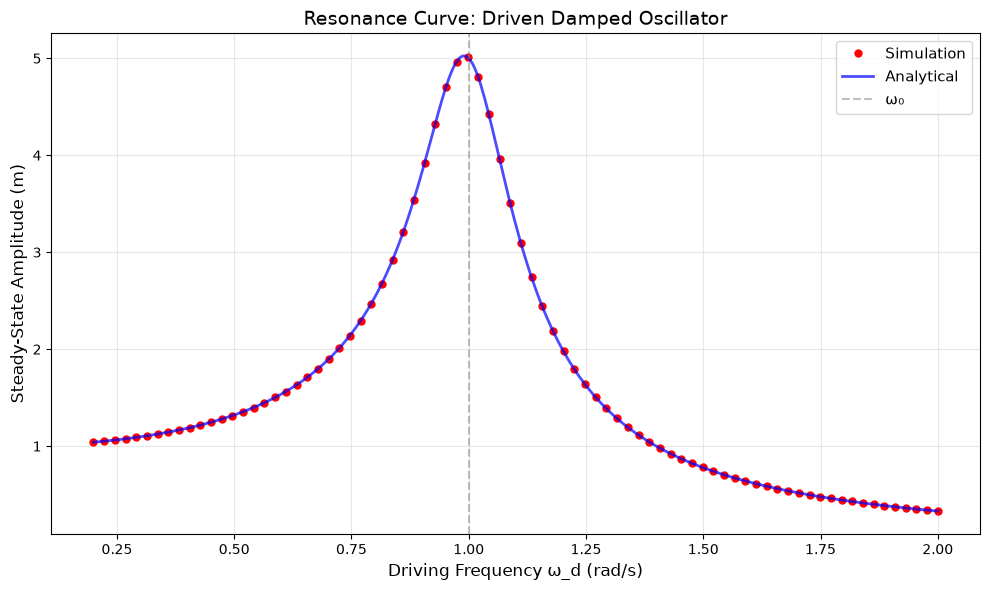

In [20]:
beta = 0.1   # light damping
F0 = 1.0     # driving amplitude

omega_values = np.linspace(0.2, 2.0, 80)
amplitudes = []

for omega_d in omega_values:
    t, x = simulate_driven_sho(omega_d, F0, beta, dt=0.01, t_max=150.0)
    # Steady-state amplitude: max of x in the last 20% of the simulation
    n_start = int(0.8 * len(x))
    amp = np.max(np.abs(x[n_start:]))
    amplitudes.append(amp)

# Analytical resonance curve for comparison
omega_exact = np.linspace(0.2, 2.0, 500)
b_val = 2 * m * beta
A_exact = (F0/m) / np.sqrt((omega0**2 - omega_exact**2)**2 + (2*beta*omega_exact)**2)

plt.figure(figsize=(10, 6))
plt.plot(omega_values, amplitudes, 'ro', markersize=5, label='Simulation')
plt.plot(omega_exact, A_exact, 'b-', linewidth=2, label='Analytical', alpha=0.7)
plt.axvline(x=omega0, color='gray', linestyle='--', alpha=0.5, label='ω₀')
plt.xlabel('Driving Frequency ω_d (rad/s)', fontsize=12)
plt.ylabel('Steady-State Amplitude (m)', fontsize=12)
plt.title('Resonance Curve: Driven Damped Oscillator', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The amplitude peaks near w subscipt zero because the driving frequency is close to the system’s natural frequency, so energy is transferred into the oscillator rather efficiently. This condition is called resonance as discussed in the textbook, and it basically produces the largest steady-state amplitude. If the damping wasn't as much as it is, there would be less energy lost during each cycle, so the resonance peak would become taller and sharper (not as spread out as it is right now). With more damping, the peak would be lower and broader than it is right now. 

Bonus: The nonlinear pendulum

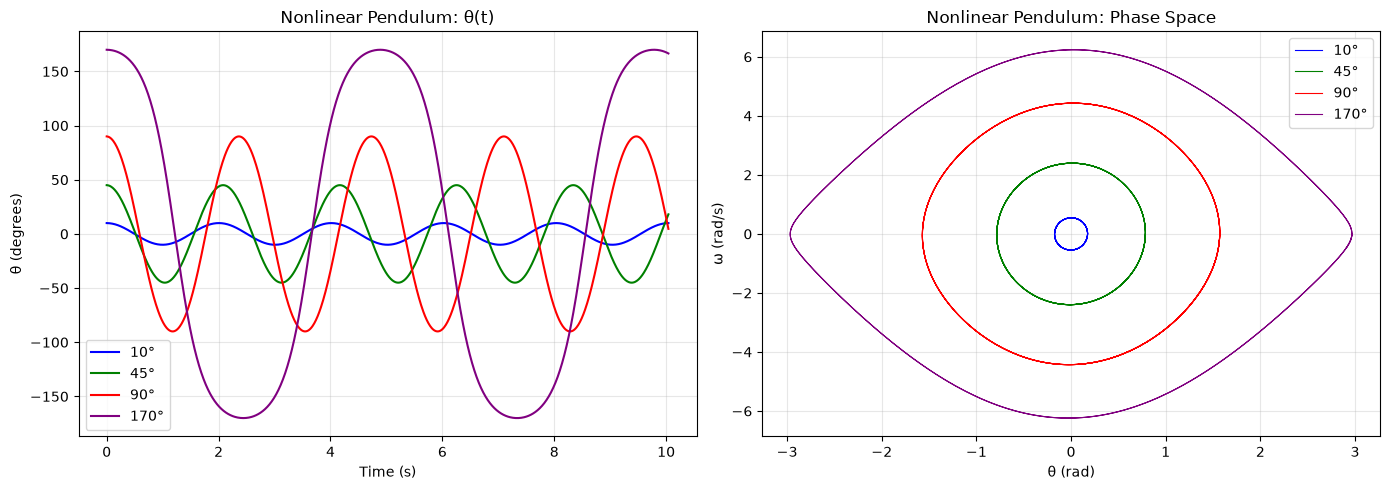

In [21]:
def simulate_pendulum(theta0_deg, dt=0.01, n_periods=5):
    """Simulate nonlinear pendulum with Euler-Cromer."""
    g_val = 9.81
    L = 1.0   # length (m)
    omega0_pend = np.sqrt(g_val / L)
    T_small = 2 * np.pi / omega0_pend  # small-angle period

    theta = np.radians(theta0_deg)
    omega_val = 0.0
    ts, thetas, omegas = [0], [theta], [omega_val]
    t = 0.0

    while t < n_periods * T_small:
        alpha = -(g_val / L) * np.sin(theta)  # nonlinear!
        omega_val += alpha * dt
        theta += omega_val * dt
        t += dt
        ts.append(t); thetas.append(theta); omegas.append(omega_val)

    return np.array(ts), np.array(thetas), np.array(omegas)

# Compare small and large angle
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for angle, color, label in [(10, 'b', '10°'), (45, 'g', '45°'), (90, 'r', '90°'), (170, 'purple', '170°')]:
    t, theta, omega_val = simulate_pendulum(angle)
    ax1.plot(t, np.degrees(theta), color=color, label=label)
    ax2.plot(theta, omega_val, color=color, label=label, linewidth=0.8)

ax1.set_xlabel('Time (s)'); ax1.set_ylabel('θ (degrees)')
ax1.set_title('Nonlinear Pendulum: θ(t)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set_xlabel('θ (rad)'); ax2.set_ylabel('ω (rad/s)')
ax2.set_title('Nonlinear Pendulum: Phase Space')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The period gets longer as the starting angle gets larger. At small angles like ten degrees, the motion is very close to the small-angle prediction. However, around 45 degrees, the period starts to differ by at least a couple eprcent. Then, at very large angles like 170 degrees, the period becomes much longer.